# Strut-and-Tie Model of a Hammerhead Pier Cap

An invented hammerhead pier: two 380-kip girder reactions land 5.5 ft either
side of a 4-ft-wide column.  The cap is 5 ft deep, so the whole region is
D-region and 5.8.2 strut-and-tie applies.

The truss idealization: loads travel down inclined struts into the column,
tied across the top by the tension chord.

In [1]:
from civilpy.structural.strut_and_tie import StrutAndTieModel
from civilpy.structural.aashto.lrfd import stm

model = StrutAndTieModel()
# top nodes at the bearings, bottom nodes at the column faces
model.add_node("A", -5.5, 4.0)     # left bearing
model.add_node("B", 5.5, 4.0)      # right bearing
model.add_node("C", -1.5, 0.0)     # column face, left
model.add_node("D", 1.5, 0.0)      # column face, right
model.add_member("A", "B")          # top tie
model.add_member("A", "C")          # inclined strut
model.add_member("B", "D")
model.add_member("C", "D")          # strut across the column head
model.add_member("A", "D")          # sway stabilizer (zero-force here)
model.add_support("C", fix_x=True, fix_y=True)
model.add_support("D", fix_y=True)
model.add_load("A", fy=-380.0)
model.add_load("B", fy=-380.0)
forces = model.solve()
for member, force in forces.items():
    kind = "tie" if force > 1e-6 else ("strut" if force < -1e-6 else "zero")
    print(f"{member}: {force:+8.1f} kips  ({kind})")

('A', 'B'):   +380.0 kips  (tie)
('A', 'C'):   -537.4 kips  (strut)
('B', 'D'):   -537.4 kips  (strut)
('C', 'D'):   -380.0 kips  (strut)
('A', 'D'):     +0.0 kips  (zero)


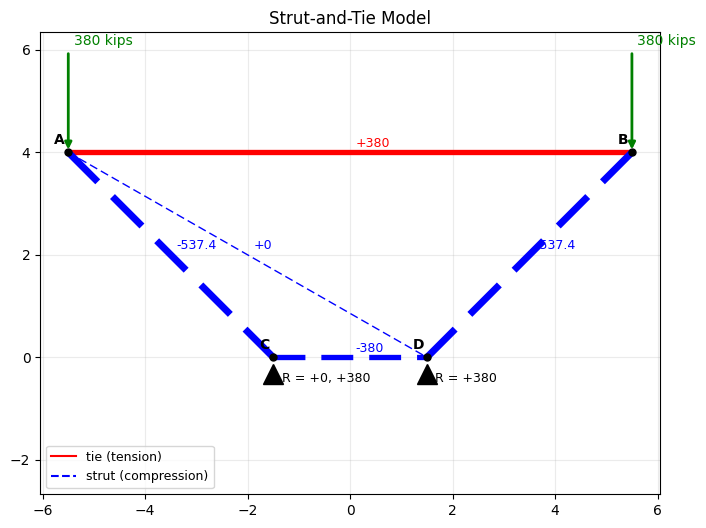

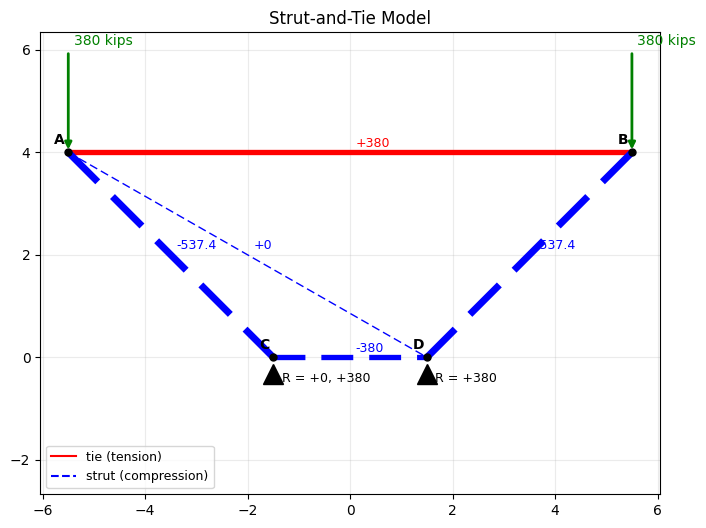

In [2]:
model.plot()

## Capacity side (5.8.2)

The top tie needs reinforcement for its 380-kip... let's check the computed tie
force, the node crushing at the bearing (CCT node), and the crack-control
mesh.

In [3]:
tie_force = forces[("A", "B")]
tie = stm.stm_tie_resistance(a_st=12.48, f_y=60.0, p_u=tie_force)  # 8 #11 bars
print(f"tie:  Pn = {tie.capacity:.0f} k, phi = {tie.phi}, "
      f"demand = {tie.demand:.0f} k -> "
      f"{'OK' if tie.factored_capacity >= tie.demand else 'NG'}")

node = stm.stm_node_resistance(
    a_cn=20.0 * 24.0, f_c=4.0, node_type="CCT", p_u=380.0)
print(f"node: Pn = {node.capacity:.0f} k, phi = {node.phi}, "
      f"demand = {node.demand:.0f} k -> "
      f"{'OK' if node.factored_capacity >= node.demand else 'NG'}")

mesh = stm.stm_crack_control_reinforcement(b_w=48.0, s_h=12.0, s_v=12.0)
print("crack control (5.8.2.6):", mesh.details)

tie:  Pn = 749 k, phi = 0.9, demand = 380 k -> OK
node: Pn = 1344 k, phi = 0.7, demand = 380 k -> OK
crack control (5.8.2.6): {'required_ratio': 0.003}


The solver, the diagram, and the code checks share one model — change the
geometry and the whole chain updates.